In [2]:
# Imports

import os
import cv2
import json
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
# Dataset Paths

DATASET_ROOT = "/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train_balanced")
VAL_DIR = os.path.join(DATASET_ROOT, "val_balanced")
TEST_DIR = os.path.join(DATASET_ROOT, "test_balanced")

CLASSES = ["CNV", "DME", "DRUSEN", "NORMAL"]

In [4]:
# Dataset Structure

for split_name, split_path in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():

    print(f"\n{split_name}")

    for cls in CLASSES:
        cls_path = os.path.join(split_path, cls)
        if not os.path.exists(cls_path):
            print(f"Missing -> {cls_path}")
        else:
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count}")


Train
CNV: 26080
DME: 8043
DRUSEN: 6073
NORMAL: 18501

Validation
CNV: 5616
DME: 1737
DRUSEN: 1327
NORMAL: 3982

Test
CNV: 5614
DME: 1734
DRUSEN: 1321
NORMAL: 3981


In [6]:
# Class Distribution Analysis

distribution = []

for split_name, split_path in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():

    for cls in CLASSES:

        cls_path = os.path.join(split_path, cls)

        count = len(os.listdir(cls_path))

        distribution.append({
            "Split": split_name,
            "Class": cls,
            "Count": count
        })

distribution_df = pd.DataFrame(distribution)
distribution_df.T

,0,1,2,3,4,5,6,7,8,9,10,11
Split,Train,Train,Train,Train,Validation,Validation,Validation,Validation,Test,Test,Test,Test
Class,CNV,DME,DRUSEN,NORMAL,CNV,DME,DRUSEN,NORMAL,CNV,DME,DRUSEN,NORMAL
Count,26080,8043,6073,18501,5616,1737,1327,3982,5614,1734,1321,3981


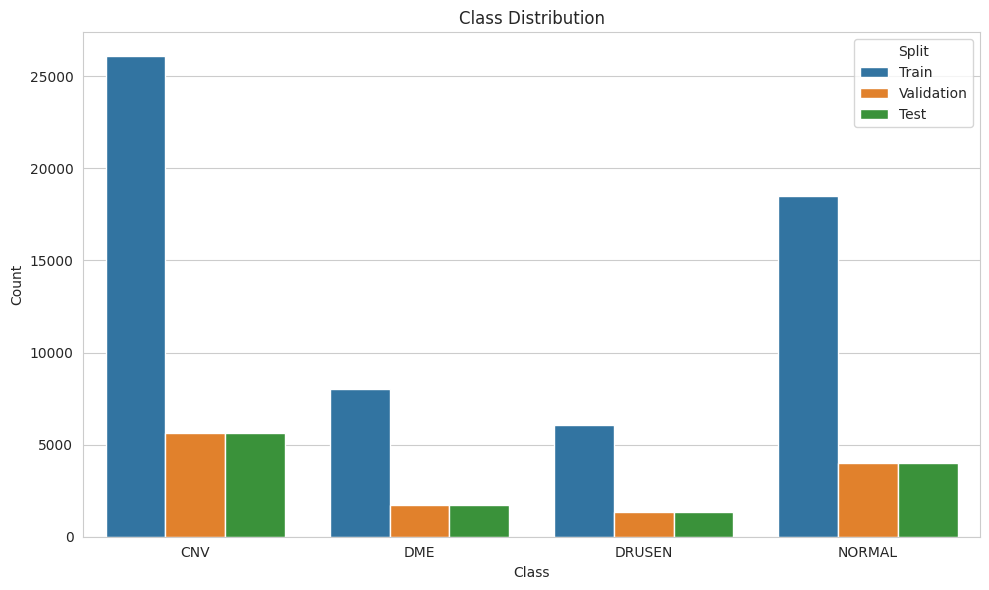

In [7]:
plt.figure(figsize=(10,6))
sns.barplot(data=distribution_df, x="Class", y="Count", hue="Split")
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

In [8]:
# Class Weights

train_counts = []

for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    train_counts.append(len(os.listdir(cls_path)))

train_counts = np.array(train_counts)
total = train_counts.sum()

class_weights = {}

for i, count in enumerate(train_counts):
    class_weights[i] = total / (len(CLASSES) * count)

print(class_weights)

{0: np.float64(0.5626629601226993), 1: np.float64(1.8244746984955862), 2: np.float64(2.416309896262144), 3: np.float64(0.7931598291984218)}


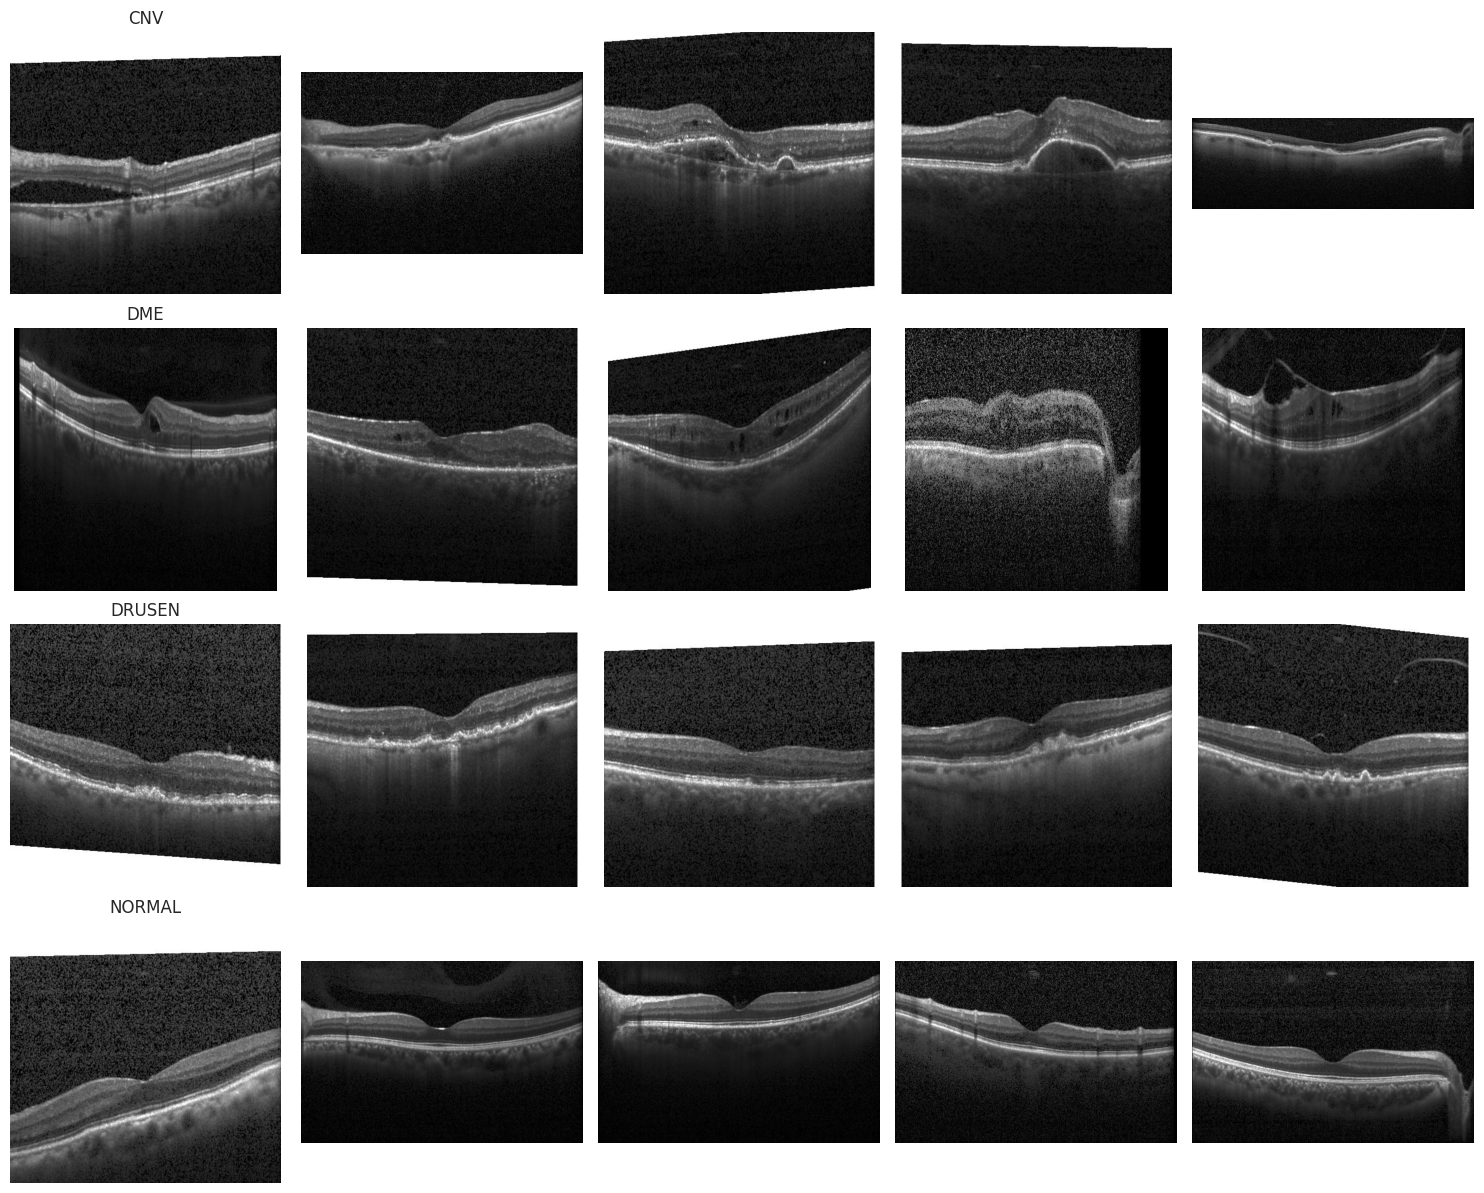

In [9]:
# Sample Images

fig, axes = plt.subplots(len(CLASSES), 5, figsize=(15,12))

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_path)[:5]
    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls)

plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

In [10]:
# Image Dimension Analysis

image_stats = []

for split_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in CLASSES:
        cls_path = os.path.join(split_path, cls)
        for img_name in tqdm(os.listdir(cls_path)):
            img_path = os.path.join(cls_path, img_name)

            try:
                img = Image.open(img_path)
                width, height = img.size
                image_stats.append({
                    "class": cls,
                    "width": width,
                    "height": height
                })
            except:
                pass

image_stats_df = pd.DataFrame(image_stats)
image_stats_df.head()

100%|██████████| 3981/3981 [00:19<00:00, 201.15it/s]


,class,width,height
0,CNV,512,496
1,CNV,768,496
2,CNV,512,496
3,CNV,512,496
4,CNV,1536,496


In [11]:
image_stats_df.describe().T

,count,mean,std,min,25%,50%,75%,max
width,84009.0,680.990656,305.280380,384.0,512.0,512.0,768.0,1536.0
height,84009.0,498.935114,6.192527,496.0,496.0,496.0,496.0,512.0


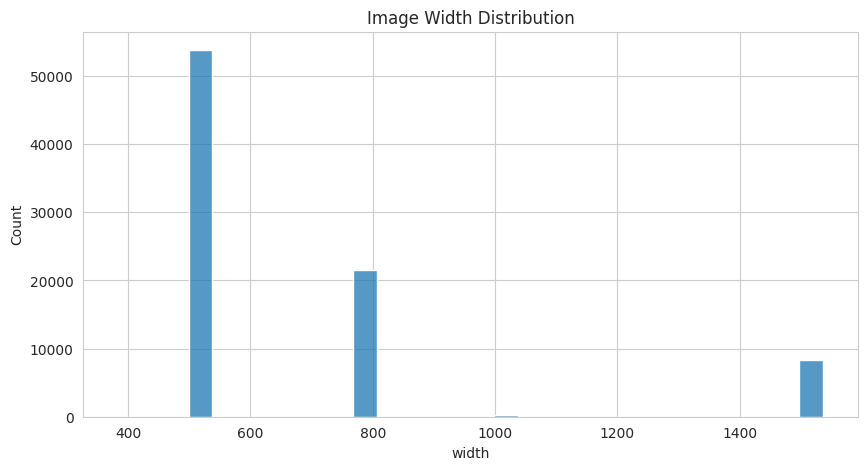

In [12]:
# Width Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    image_stats_df["width"],
    bins=30
)

plt.title("Image Width Distribution")
plt.show()

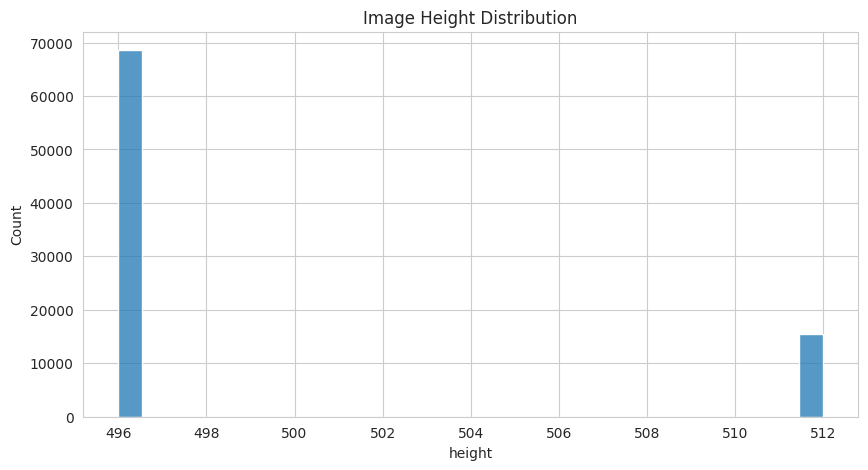

In [13]:
# Height Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    image_stats_df["height"],
    bins=30
)

plt.title("Image Height Distribution")
plt.show()

In [14]:
low_res = image_stats_df[
    image_stats_df["width"] <= 496
]

print("Low Resolution Images:")
print(len(low_res))

Low Resolution Images:
16


In [17]:
# Pixel Intensity Stats

pixel_sum = 0
pixel_sq_sum = 0
pixel_count = 0

sample_limit = 10000
processed = 0

for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    
    for img_name in tqdm(os.listdir(cls_path)):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = img.astype(np.float32) / 255.0
        pixel_sum += img.sum()
        pixel_sq_sum += (img**2).sum()
        pixel_count += img.size
        processed += 1
        if processed >= sample_limit:
            break

    if processed >= sample_limit:
        break

mean = pixel_sum / pixel_count
std = np.sqrt(pixel_sq_sum / pixel_count - mean**2)

print(f"Mean : {mean:.5f}")
print(f"Std  : {std:.5f}")

 38%|███▊      | 9999/26080 [00:42<01:08, 235.44it/s]

Mean : 0.18599
Std  : 0.21545


In [16]:
class_stats = []

for cls in CLASSES:

    pixels = []

    cls_path = os.path.join(TRAIN_DIR, cls)

    files = os.listdir(cls_path)[:1000]

    for img_name in tqdm(files):

        img_path = os.path.join(cls_path, img_name)

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is not None:
            pixels.append(
                img.flatten()
            )

    pixels = np.concatenate(pixels)

    class_stats.append({
        "Class": cls,
        "Mean": pixels.mean(),
        "Std": pixels.std(),
        "Min": pixels.min(),
        "Max": pixels.max()
    })

class_stats_df = pd.DataFrame(class_stats)

class_stats_df

100%|██████████| 1000/1000 [00:04<00:00, 241.40it/s]


,Class,Mean,Std,Min,Max
0,CNV,46.430306,53.876607,0,255
1,DME,48.861687,57.268226,0,255
2,DRUSEN,46.372038,54.446747,0,255
3,NORMAL,42.876066,51.562322,0,255


In [18]:
stats = {
    "classes": CLASSES,
    "class_weights": class_weights,
    "dataset_mean": float(mean),
    "dataset_std": float(std)
}

with open("dataset_stats.json", "w") as f:
    json.dump(stats, f, indent=4)

print("Saved dataset_stats.json")

Saved dataset_stats.json


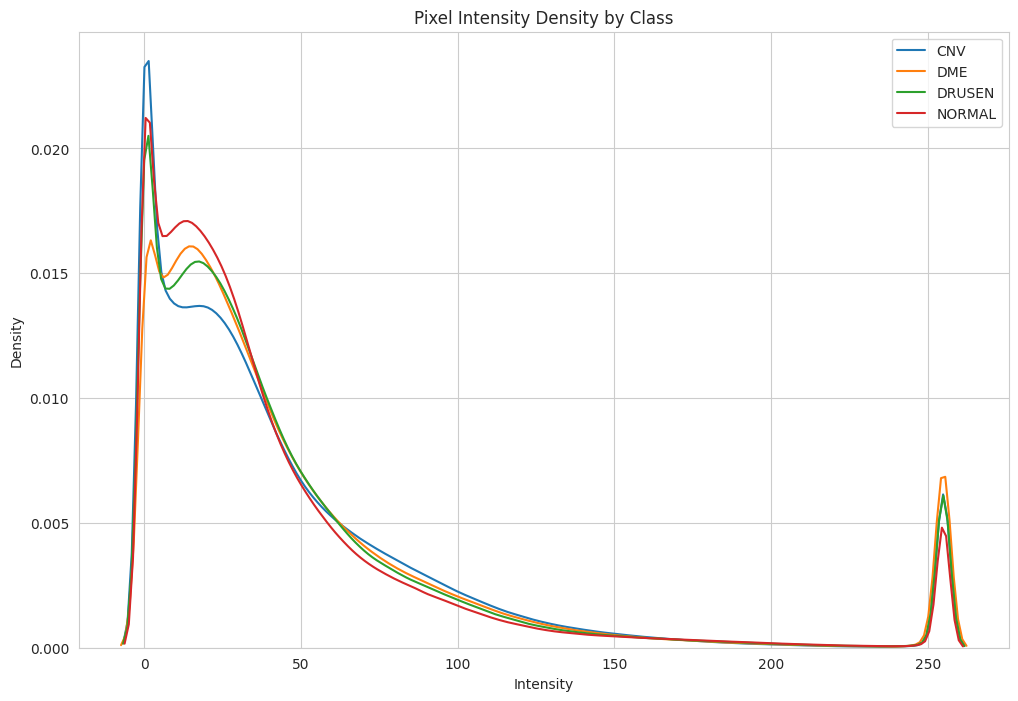

In [7]:
plt.figure(figsize=(12,8))

for cls in CLASSES:
    pixels = []
    cls_path = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(cls_path)[:500]
    for img_name in files:
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            pixels.extend(img.flatten()[::20])

    sns.kdeplot(pixels, label=cls)

plt.title("Pixel Intensity Density by Class")
plt.xlabel("Intensity")
plt.legend()
plt.savefig('class-wise-pixel-intensity-distribution.png')
plt.show()